In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [ ]:
# Normalize (VERY IMPORTANT)
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [ ]:
# Save original labels for evaluation
y_test_labels = y_test.copy()

In [ ]:
from tensorflow.keras.utils import to_categorical

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
# ✅ 4. Model Function
def create_model(activation_func):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation_func),
        Dense(64, activation=activation_func),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# ✅ 5. Train Models
activations = ['sigmoid', 'relu', 'tanh']
models = {}
histories = {}
accuracies = {}

for act in activations:
    print(f"\nTraining model with {act}...")

    model = create_model(act)

    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    models[act] = model
    histories[act] = history
    accuracies[act] = acc



Training model with sigmoid...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7530 - loss: 0.7834 - val_accuracy: 0.8309 - val_loss: 0.4740
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8469 - loss: 0.4304 - val_accuracy: 0.8590 - val_loss: 0.4002
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8637 - loss: 0.3793 - val_accuracy: 0.8637 - val_loss: 0.3780
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8720 - loss: 0.3530 - val_accuracy: 0.8629 - val_loss: 0.3724
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8784 - loss: 0.3361 - val_accuracy: 0.8741 - val_loss: 0.3449

Training model with relu...
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8117 - loss: 0.5390 - val_accuracy: 0.8435 - val_loss: 0.4288
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8605 - loss: 0.3912 - val_accuracy: 0.8634 - val_loss: 0.3799
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8740 - loss: 0.34


Final Accuracy:
sigmoid: 0.8659
relu: 0.8626
tanh: 0.8707


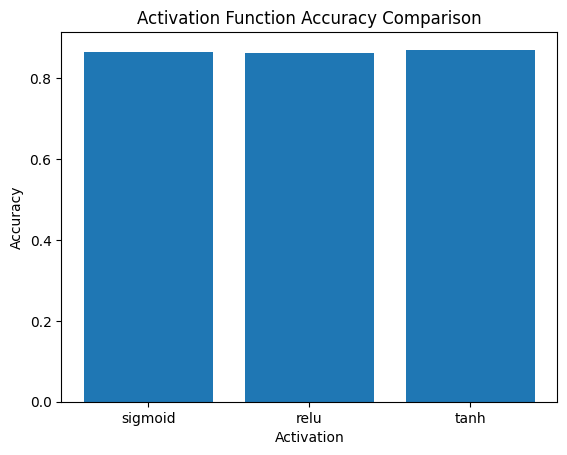

In [ ]:
# ✅ 6. Accuracy Comparison
print("\nFinal Accuracy:")
for act in accuracies:
    print(f"{act}: {accuracies[act]:.4f}")

plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.title("Activation Function Accuracy Comparison")
plt.xlabel("Activation")
plt.ylabel("Accuracy")
plt.show()



===== SIGMOID MODEL =====
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


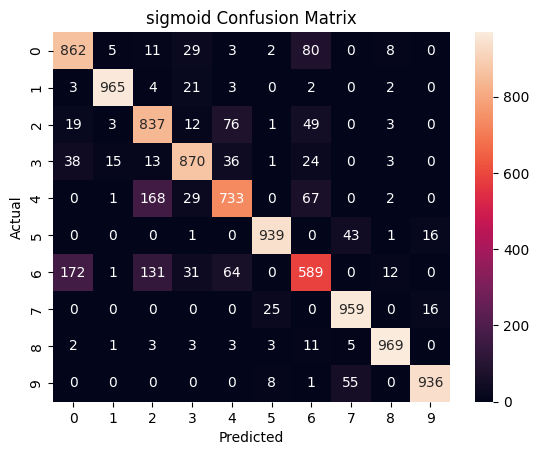


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.79      0.86      0.82      1000
     Trouser       0.97      0.96      0.97      1000
    Pullover       0.72      0.84      0.77      1000
       Dress       0.87      0.87      0.87      1000
        Coat       0.80      0.73      0.76      1000
      Sandal       0.96      0.94      0.95      1000
       Shirt       0.72      0.59      0.65      1000
     Sneaker       0.90      0.96      0.93      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.86     10000
weighted avg       0.87      0.87      0.86     10000


===== RELU MODEL =====
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


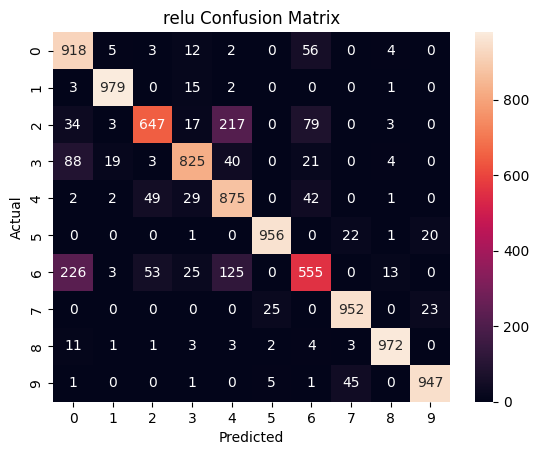


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.72      0.92      0.80      1000
     Trouser       0.97      0.98      0.97      1000
    Pullover       0.86      0.65      0.74      1000
       Dress       0.89      0.82      0.86      1000
        Coat       0.69      0.88      0.77      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.73      0.56      0.63      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000


===== TANH MODEL =====
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


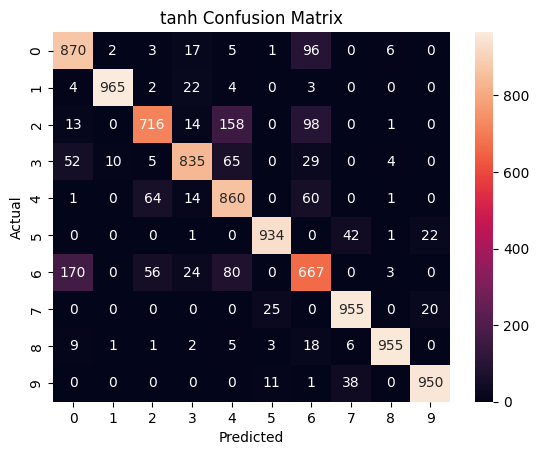


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.78      0.87      0.82      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.85      0.72      0.78      1000
       Dress       0.90      0.83      0.87      1000
        Coat       0.73      0.86      0.79      1000
      Sandal       0.96      0.93      0.95      1000
       Shirt       0.69      0.67      0.68      1000
     Sneaker       0.92      0.95      0.94      1000
         Bag       0.98      0.95      0.97      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [ ]:
#  ✅ 8. Confusion Matrix + Report (for each model)
for act in models:
    print(f"\n===== {act.upper()} MODEL =====")

    model = models[act]

    # Predictions
    y_pred = model.predict(x_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Confusion Matrix
    cm = confusion_matrix(y_test_labels, y_pred_classes)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{act} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test_labels, y_pred_classes, target_names=class_names))